Shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

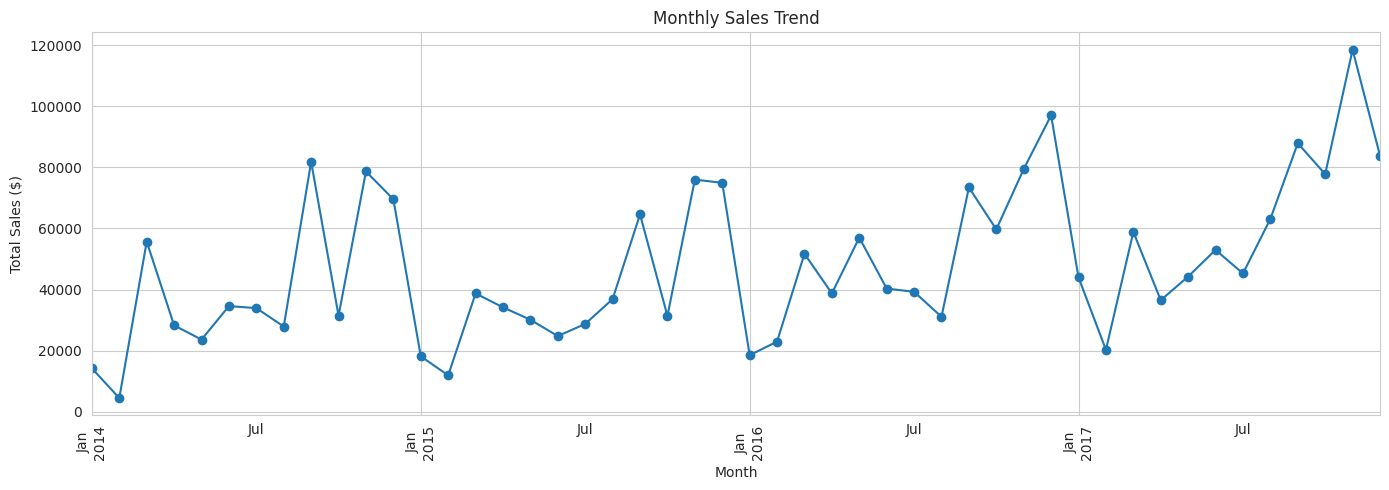

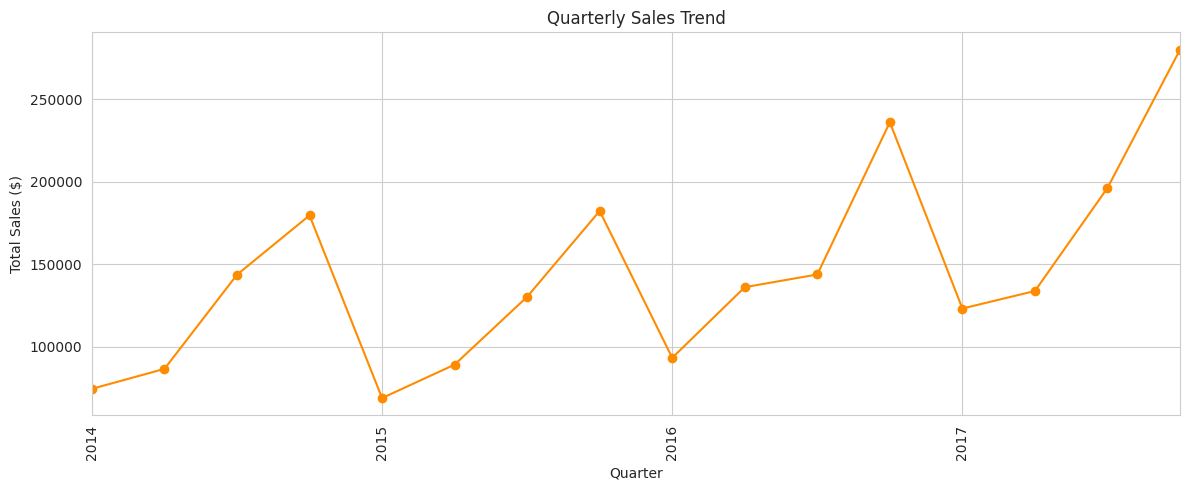

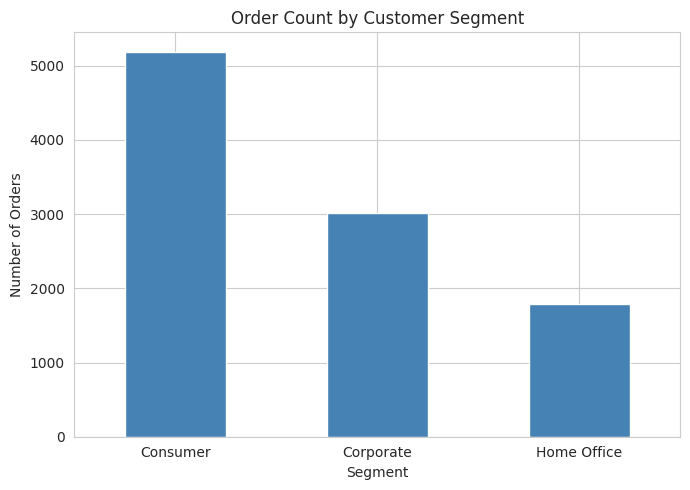

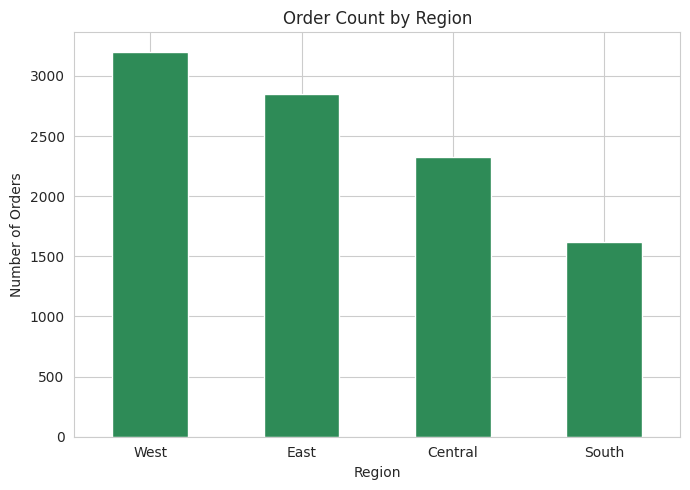

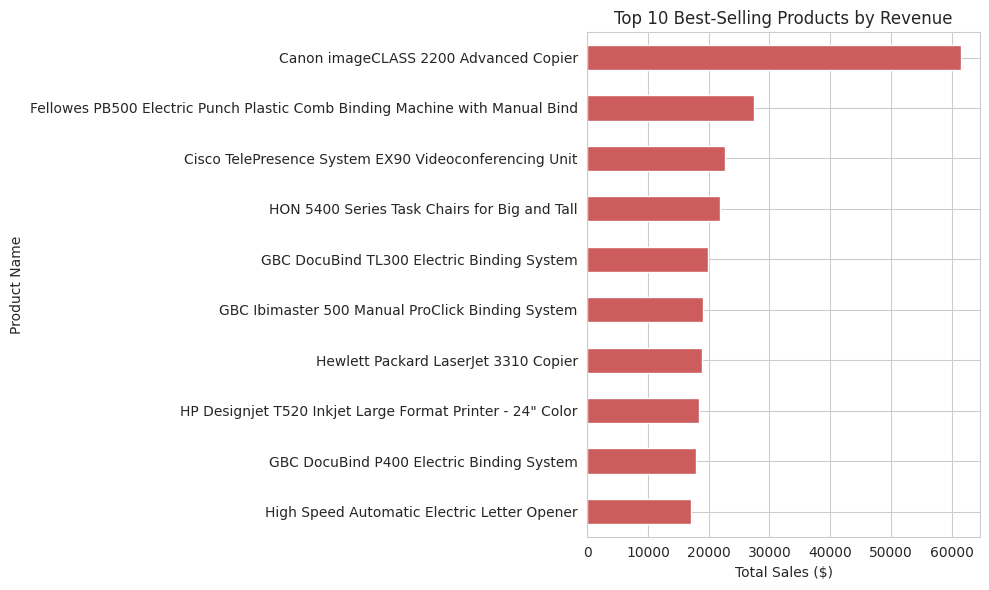

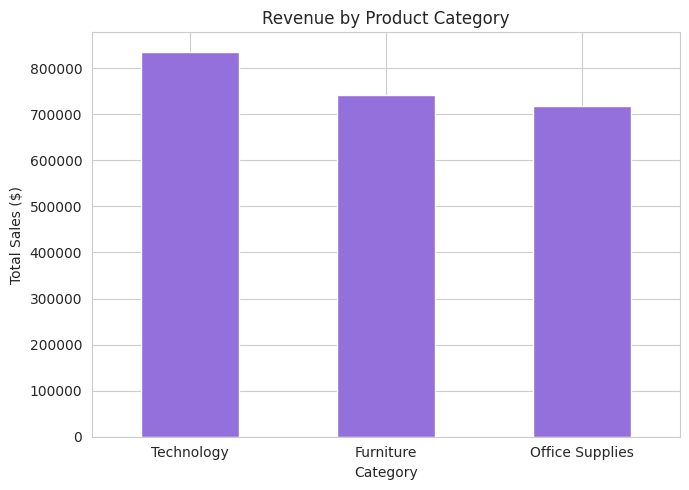

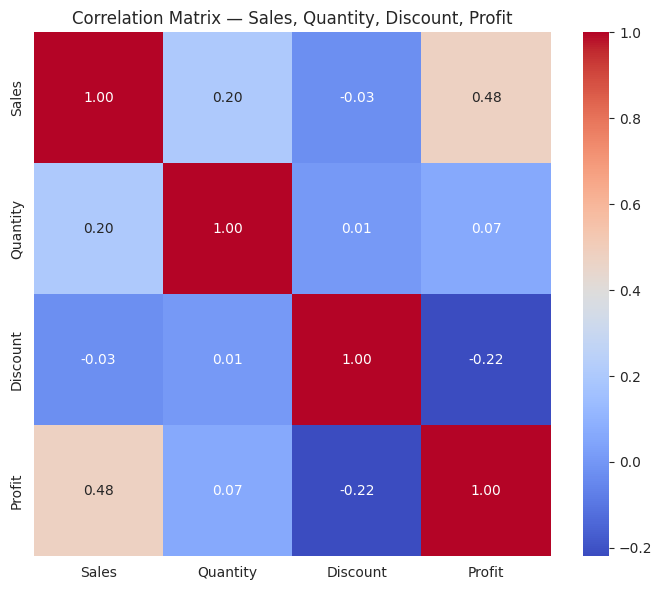

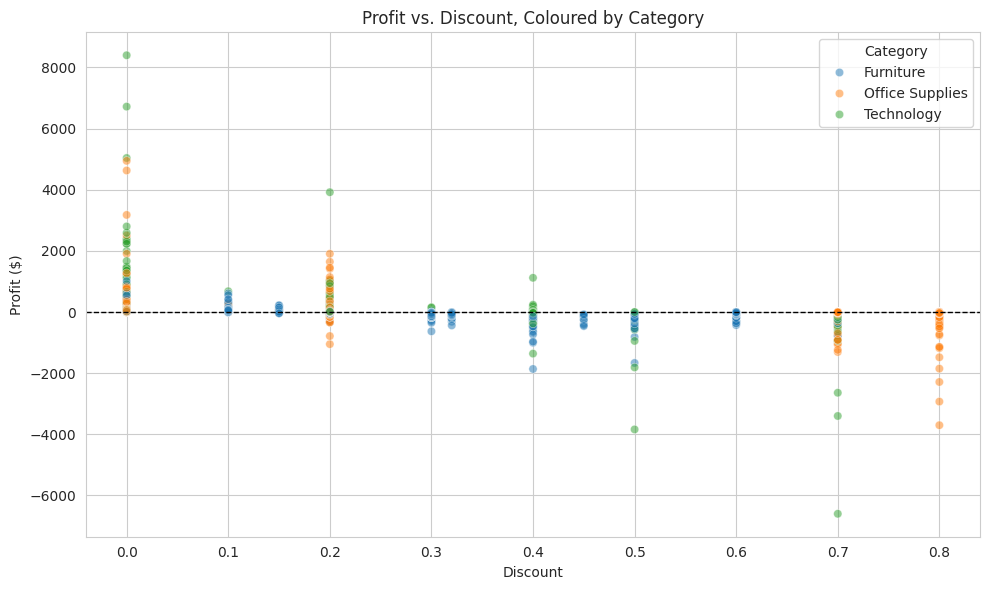

In [1]:
# # OIBSIP — Data Analytics Track
# ## Task: EDA on Retail Sales Data (Superstore Dataset)
# 
# **Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover
# patterns, customer behaviour trends, and actionable business insights.
# 
# **Dataset:** Sample Superstore Dataset (Kaggle — vivek468/superstore-dataset-final)
# **Author:** Syed Azmul Hasan
# **Track:** Data Analytics
# 
# **Note on dataset fit:** This task's checklist mentions "customer age groups and gender breakdown."
# The Superstore dataset does not include age or gender fields. As a transparent substitute, this
# notebook analyses **Customer Segment** and **Region** as the customer-profile dimensions instead —
# these are the demographic-style fields this dataset actually provides.
# 

# ## Step 0 — Imports and Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# ## Step 1 — Load Dataset and Initial Inspection

DATA_PATH = "/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv"

# Superstore CSV is commonly saved with latin-1 encoding
df = pd.read_csv(DATA_PATH, encoding='latin-1')

print("Shape:", df.shape)
df.head()


df.info()


print("Null values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


# **Observation:** The dataset is generally clean already (Superstore is a well-known benchmark
# dataset). We'll still parse dates properly and check dtypes before analysis.
# 

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
df['Order Year'] = df['Order Date'].dt.year

df[['Order Date', 'Ship Date', 'Order Month', 'Order Quarter']].head()


# ## Step 2 — Descriptive Statistics
# 
# Mean, median, mode, and standard deviation for all key numerical columns.
# 

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

desc_stats = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': df[numeric_cols].mode().iloc[0],
    'std_dev': df[numeric_cols].std()
})

desc_stats


# **Observation:** `Discount` has a low mean with many zero values (mode 0), meaning most orders
# ship without a discount. `Profit` has a much larger standard deviation relative to its mean than
# `Sales`, hinting at inconsistent profitability across orders — some orders are likely sold at a loss.
# 

# ## Step 3 — Time Series Analysis: Monthly and Quarterly Sales Trends
# 

monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(12, 5))
quarterly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# **Observation:** Sales show a clear seasonal pattern, with noticeable spikes toward the end of most
# years (Nov–Dec) — consistent with holiday-season retail buying, and a recurring dip early in each year.
# 

# ## Step 4 — Customer Profile Analysis (Segment & Region)
# 
# *(Substituting for age/gender, which this dataset does not contain — see note above.)*
# 

segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(7, 5))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Order Count by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

segment_counts


region_counts = df['Region'].value_counts()

plt.figure(figsize=(7, 5))
region_counts.plot(kind='bar', color='seagreen')
plt.title('Order Count by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

region_counts


# **Observation:** The `Consumer` segment drives the largest share of orders, and the `West` and
# `East` regions lead in order volume — useful for prioritising regional marketing and stock allocation.
# 

# ## Step 5 — Product Analysis: Top Products and Revenue by Category
# 

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='indianred')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

top_products


category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
category_revenue.plot(kind='bar', color='mediumpurple')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

category_revenue


# **Observation:** `Technology` and `Furniture` typically generate the highest revenue per category,
# even though `Office Supplies` often has the highest order *count* — meaning Office Supplies orders
# tend to be smaller-ticket, high-frequency purchases.
# 

# ## Step 6 — Correlation Heatmap
# 

plt.figure(figsize=(7, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.show()


# **Observation:** `Discount` typically shows a *negative* correlation with `Profit` — higher discounts
# are associated with lower profit, which is worth flagging for the business.
# 

# ## Step 7 — Additional Insight: Profit vs. Discount by Category
# 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
plt.title('Profit vs. Discount, Coloured by Category')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


# **Observation (non-obvious insight):** Once discounts climb past roughly 20–30%, a large cluster of
# orders — especially in `Furniture` — actually cross into **negative profit** (below the dashed zero
# line). This suggests the discounting strategy for certain categories may be eroding margin rather than
# just boosting volume.
# 

# ## Conclusion — Business Recommendations
# 
# 1. **Rein in deep discounting on Furniture.** The Profit vs. Discount chart shows Furniture orders
#    consistently turn unprofitable above ~20–30% discount. Capping discount tiers for this category
#    could protect margin without necessarily hurting volume much.
# 
# 2. **Double down on Technology and West/East regions.** Technology drives the highest per-order
#    revenue, and the West and East regions already lead in order volume — targeted promotions or
#    inventory prioritisation in these areas is likely to compound existing strength rather than
#    chase weaker segments.
# 
# 3. **Plan inventory and staffing around the Nov–Dec seasonal spike.** The monthly sales trend shows
#    a repeatable late-year surge. Building this into procurement and staffing schedules ahead of time
#    should reduce stockouts and missed sales during the highest-demand window.
#